# 06 · Segmentación (K-means + PCA) y red neuronal (T-08, bloques G e I)

**Dónde:** `pipeline/src/ml/segmentos.py` y `pipeline/src/deep_learning/mlp.py`. **Por qué:** agrupar tomas con
comportamiento parecido para priorizar acciones, y probar si una red neuronal mejora al mejor modelo clásico.
**Cómo:** K elegido por silhouette y PCA de 2 componentes; MLP en PyTorch (64-32, dropout, parada temprana) contra
Gradient Boosting con la misma separación temporal de T-07. **Con qué datos:** variables por toma y por recibo de T-04/T-07.

In [1]:
import sys, pathlib
raiz = pathlib.Path.cwd()
while not (raiz / "pipeline").exists() and raiz != raiz.parent:
    raiz = raiz.parent
sys.path.insert(0, str(raiz))
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.max_colwidth", 120)
from pipeline.notebooks.graficas import dibujar, tabla

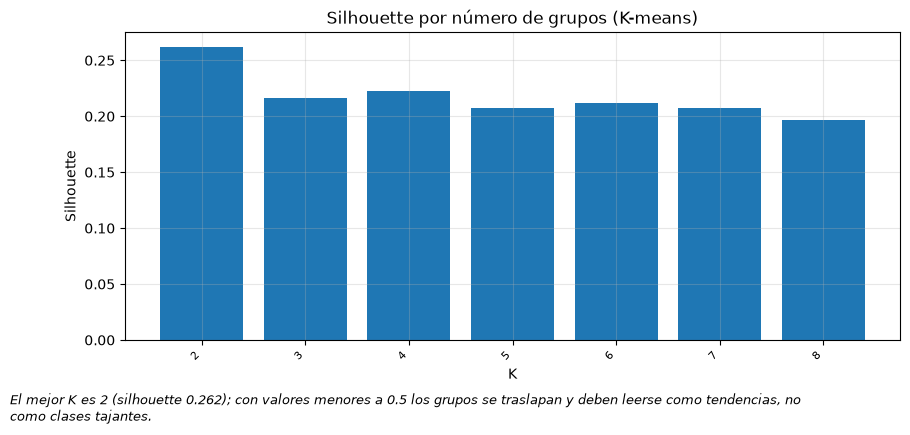

**Perfil de los 2 segmentos de tomas (medias)**

,segmento,nombre,tomas,consumo_medio,consumo_cv,estacionalidad,tasa_tardio,domiciliado,pct_lecturas_inconsistentes,antiguedad_meses
0,0,comportamiento típico,396,20.415,0.323,1.121,0.289,0.0,0.011,58.783
1,1,"puntual, domiciliado",84,18.361,0.309,1.124,0.060,1.0,0.013,53.940


_Segmentos: 0 = comportamiento típico (396 tomas); 1 = puntual, domiciliado (84 tomas). La separación principal es domiciliado/puntual contra el resto: la segmentación confirma H2 más que descubrir grupos nuevos._  
`fuente: pipeline/src/ml/segmentos.py · pipeline/notebooks/06_segmentos_dl.ipynb`

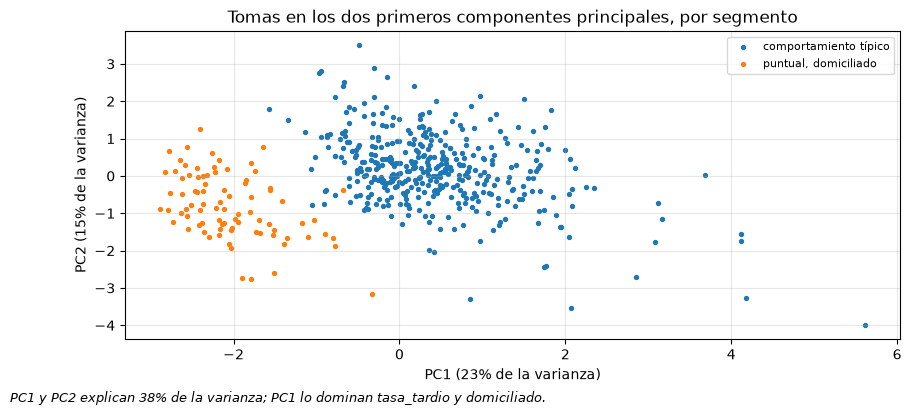

In [2]:
from pipeline.src.ml import segmentos
seg_res, seg = segmentos.ejecutar()
for x in seg_res:
    dibujar(x["payload"])

**Red neuronal (MLP) contra Gradient Boosting — misma prueba temporal**

,modelo,pr_auc,roc_auc,umbral,f1
0,MLP PyTorch (64-32),0.4251,0.7233,0.50,0.4874
1,Gradient Boosting,0.4275,0.7207,0.47,0.4929


_Gana Gradient Boosting por PR-AUC (0.425 MLP contra 0.427 GB). La red tiene 4,289 parámetros y entrenó 12 épocas con parada temprana. En datos tabulares de este tamaño no supera a los árboles; GB es más simple de explicar y mantener._  
`fuente: pipeline/src/deep_learning/mlp.py · pipeline/notebooks/06_segmentos_dl.ipynb`

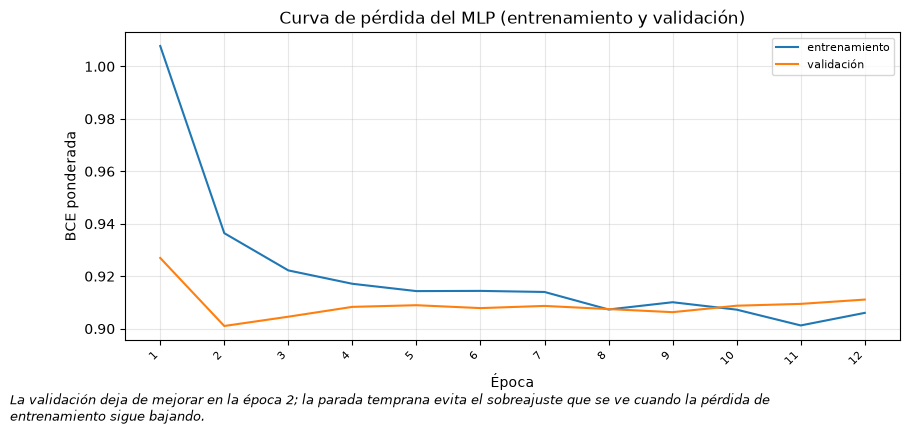

In [3]:
from pipeline.src.deep_learning import mlp
dl = mlp.ejecutar()
for x in dl:
    dibujar(x["payload"])

## Conclusiones

In [4]:
for x in seg_res + dl:
    print(f"- {x['payload']['titulo']}: {x['payload']['conclusion']}")

- Silhouette por número de grupos (K-means): El mejor K es 2 (silhouette 0.262); con valores menores a 0.5 los grupos se traslapan y deben leerse como tendencias, no como clases tajantes.
- Perfil de los 2 segmentos de tomas (medias): Segmentos: 0 = comportamiento típico (396 tomas); 1 = puntual, domiciliado (84 tomas). La separación principal es domiciliado/puntual contra el resto: la segmentación confirma H2 más que descubrir grupos nuevos.
- Tomas en los dos primeros componentes principales, por segmento: PC1 y PC2 explican 38% de la varianza; PC1 lo dominan tasa_tardio y domiciliado.
- Red neuronal (MLP) contra Gradient Boosting — misma prueba temporal: Gana Gradient Boosting por PR-AUC (0.425 MLP contra 0.427 GB). La red tiene 4,289 parámetros y entrenó 12 épocas con parada temprana. En datos tabulares de este tamaño no supera a los árboles; GB es más simple de explicar y mantener.
- Curva de pérdida del MLP (entrenamiento y validación): La validación deja de mejorar en la época 2